# EXPT NO: 6C
## DATA VISUALIZATION USING POWER BI – IPL SPORTS ANALYTICS

### Aim
To clean, preprocess, and transform IPL ball-by-ball data, prepare core metrics for Power BI, and build an interactive dashboard for match, scoring, and wicket analysis.

> Adapted to the IPL dataset from the lab manual's Experiment 6C Power BI workflow. The actual `.pbix` dashboard should be created in Power BI Desktop.


### Algorithm
1. Import the IPL ball-by-ball dataset into Power BI.
2. Identify duplicate records and missing values.
3. Handle sparse/null fields and remove unnecessary empty fields if required.
4. Format `start_date` as a Date and numeric columns with appropriate types.
5. Create calculated fields such as `total_runs` and `is_wicket`.
6. Load the cleaned table into Power BI.
7. Create core measures such as Total Runs, Total Matches, Total Deliveries and Total Wickets.
8. Create suitable charts for season-wise runs, team-wise runs and wicket types.
9. Add slicers/filters such as Season, Batting Team and Venue.
10. Arrange the visuals into an interactive dashboard and save the `.pbix` report.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("IPL_ball_by_ball_updated.csv")
print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()


Dataset loaded successfully
Rows: 243815
Columns: 22


,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,runs_off_bat,extras,wides,noballs,byes,legbyes,penalty,wicket_type,player_dismissed,other_wicket_type,other_player_dismissed
0,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.1,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,BB McCullum,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN
1,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.2,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.3,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.4,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,335982,2008,2008-04-18,M Chinnaswamy Stadium,1,0.5,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,SC Ganguly,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Data quality inspection
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
display(df.isna().sum().to_frame("Missing Values"))


Duplicate rows: 0

Missing values:


,Missing Values
match_id,0
season,0
start_date,0
venue,0
innings,0
ball,0
batting_team,0
bowling_team,0
striker,0
non_striker,0


In [3]:
# Data transformation / preprocessing
df["start_date"] = pd.to_datetime(df["start_date"], errors="coerce")

numeric_cols = ["wides", "noballs", "byes", "legbyes", "penalty"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["total_runs"] = df["runs_off_bat"] + df["extras"].fillna(0)
df["is_wicket"] = df["wicket_type"].notna().astype(int)
df["season"] = df["season"].astype(int)

print("Transformed columns added: total_runs, is_wicket")
print("Date range:", df["start_date"].min().date(), "to", df["start_date"].max().date())
print("Total runs:", int(df["total_runs"].sum()))
print("Total wickets:", int(df["is_wicket"].sum()))


Transformed columns added: total_runs, is_wicket
Date range: 2008-04-18 to 2023-05-29
Total runs: 321784
Total wickets: 12067


In [4]:
# Core metrics
metrics = pd.DataFrame({
    "Metric": ["Total Matches", "Total Deliveries", "Total Runs", "Total Wickets", "Seasons"],
    "Value": [
        df["match_id"].nunique(),
        len(df),
        int(df["total_runs"].sum()),
        int(df["is_wicket"].sum()),
        df["season"].nunique()
    ]
})
metrics


,Metric,Value
0,Total Matches,1024
1,Total Deliveries,243815
2,Total Runs,321784
3,Total Wickets,12067
4,Seasons,16


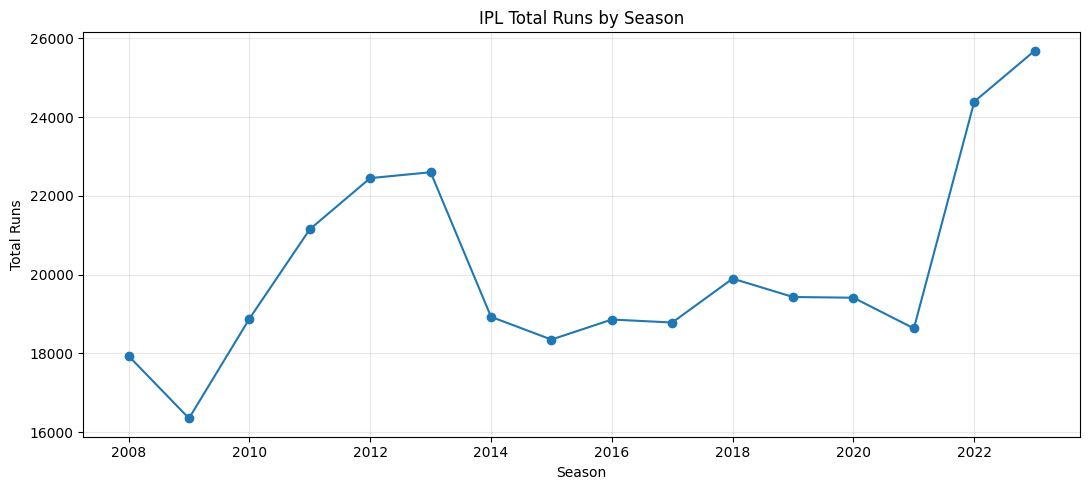

In [5]:
# Season-wise total runs
season_runs = df.groupby("season")["total_runs"].sum()

plt.figure(figsize=(11,5))
season_runs.plot(kind="line", marker="o")
plt.title("IPL Total Runs by Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


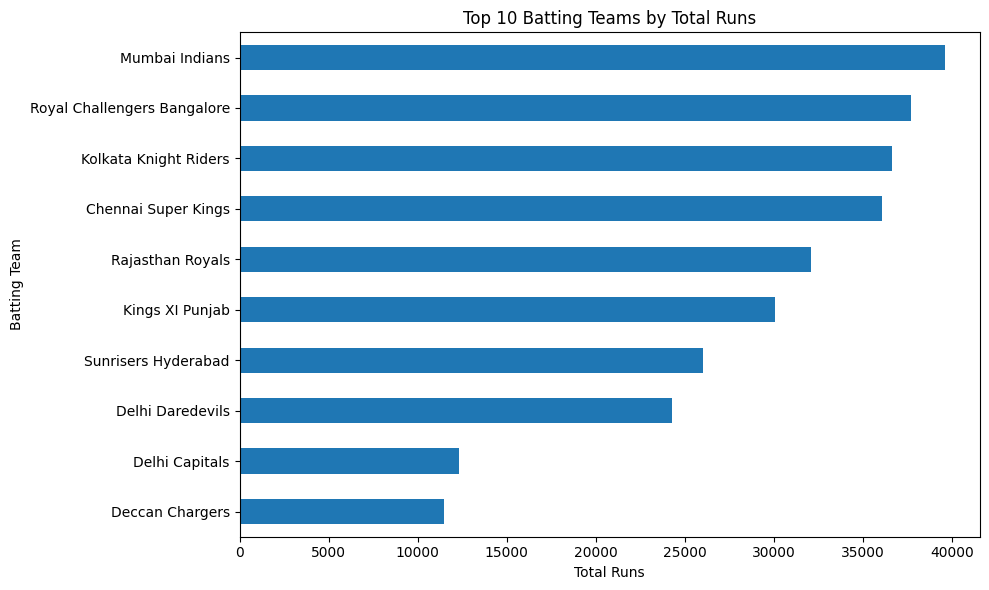

In [6]:
# Top batting teams by total runs
team_runs = df.groupby("batting_team")["total_runs"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
team_runs.sort_values().plot(kind="barh")
plt.title("Top 10 Batting Teams by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Batting Team")
plt.tight_layout()
plt.show()


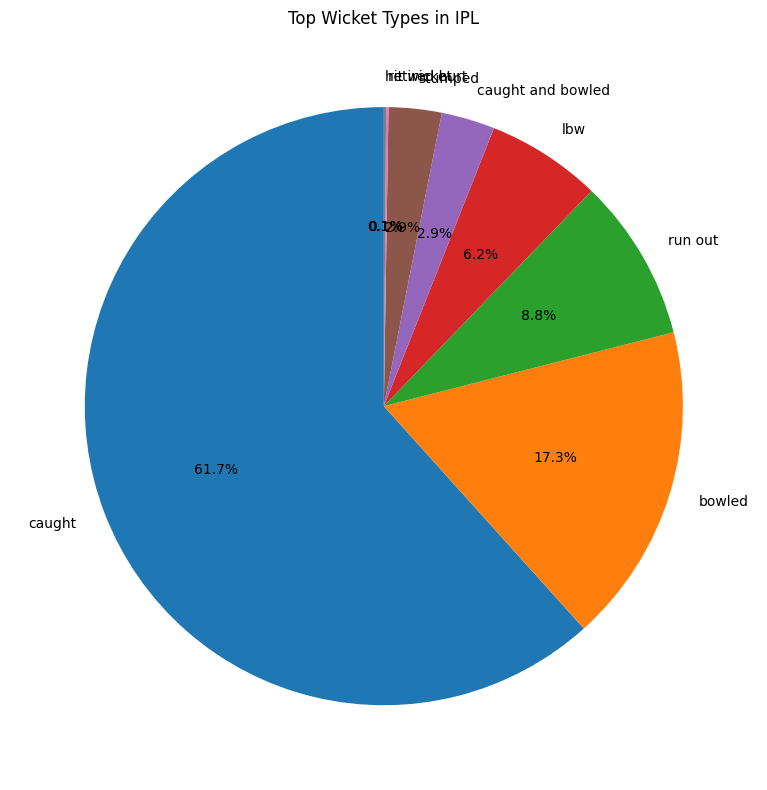

In [7]:
# Wicket-type distribution
wicket_counts = df.loc[df["wicket_type"].notna(), "wicket_type"].value_counts().head(8)

plt.figure(figsize=(8,8))
plt.pie(wicket_counts.values, labels=wicket_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Top Wicket Types in IPL")
plt.tight_layout()
plt.show()


In [8]:
# Power BI calculated-column / measure examples
print("DAX examples for Power BI:")
print('Total Runs = SUM(IPL[total_runs])')
print('Total Matches = DISTINCTCOUNT(IPL[match_id])')
print('Total Deliveries = COUNTROWS(IPL)')
print('Total Wickets = SUM(IPL[is_wicket])')


DAX examples for Power BI:
Total Runs = SUM(IPL[total_runs])
Total Matches = DISTINCTCOUNT(IPL[match_id])
Total Deliveries = COUNTROWS(IPL)
Total Wickets = SUM(IPL[is_wicket])


### Power BI Dashboard Design
Recommended visuals:
- **Card:** Total Runs, Total Matches, Total Deliveries, Total Wickets
- **Line Chart:** Season vs Total Runs
- **Bar Chart:** Batting Team vs Total Runs
- **Donut Chart:** Wicket Type distribution
- **Slicers:** Season, Batting Team, Bowling Team, Venue
- **Filters:** Date range and innings

The final interactive dashboard and `.pbix` file must be created in Power BI Desktop.


### Result
The IPL ball-by-ball dataset was cleaned and transformed, core sports metrics were calculated, and visualizations were generated for use in an interactive Power BI dashboard.
